# mm-pipeline — end-to-end example

This notebook shows the mm-pipeline run end-to-end on a small synthetic mother-machine trench bundled with the package (under `example_data/`, generated with [SyMBac](https://github.com/georgeoshardo/SyMBac)). Two examples on the same trench:

- **Example A** — DP baseline (no scorer): `track-generate → featurise → track-select → tracks`
- **Example B** — Classifier-driven: `track-generate → featurise → score → track-select → tracks`

After each example we wrap the reconstructed run in a `Lineage` (from the `mm_pipeline.analysis` module) and plot:

1. A **length time series** along the mother lineage (the cell at the closed end, followed across divisions).
2. A **swimlane** showing every track's spatial position over time, with division connectors and the mother lineage highlighted.
3. A **dendrogram** — a genealogy-first view of the same lineage.

> For a full tour of the analysis module (selectors, per-cell properties, cycle metrics, and interactive branch selection), see `analysis_tour.ipynb`.

## 1. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from mm_pipeline.config.schemas import DatasetSpec
from mm_pipeline.features.pairwise import build_feature_dataframe
from mm_pipeline.runners import (
    run_track_generate,
    run_featurise,
    run_track_select,
    run_score,
    run_train_scorer,
)

from mm_pipeline.analysis import (
    Lineage,
    mother_branch,
    plot_swimlane,
    plot_dendrogram,
    plot_property_series,
)

EXAMPLE_DATA = Path("../example_data")

ds = DatasetSpec(
    dataset_id="symbac_vid2",
    labels_dir=EXAMPLE_DATA / "labels",
    gt_tracks_csv=EXAMPLE_DATA / "gt_tracks.csv",
    gt_divisions_csv=EXAMPLE_DATA / "gt_divisions.csv",
    axis="y",
    open_end="high",
)
specs = [ds]

print(f"Dataset: {ds.dataset_id}")
print(f"  labels: {ds.labels_dir}")
print(f"  GT tracks: {ds.gt_tracks_csv}")
print(f"  GT divisions: {ds.gt_divisions_csv}")

Dataset: symbac_vid2
  labels: ../example_data/labels
  GT tracks: ../example_data/gt_tracks.csv
  GT divisions: ../example_data/gt_divisions.csv


## 2. Lineage analysis

Lineage tracing and plotting come from the `mm_pipeline.analysis` module. We wrap each reconstructed run in a `Lineage`, then:

- `mother_branch(lin)` traces the chain of `track_id`s forming the mother lineage — the cell at the closed end, followed across divisions;
- `plot_swimlane` / `plot_dendrogram` / `plot_property_series` render the lineage (each returns the `Axes`).

This replaces the block of inline helpers the notebook used to carry.

## 3. Prep — train a candidate-plausibility scorer

**One-off step.** In production you'd be given a trained scorer (a `.joblib` file). We train one here so the notebook is self-contained, using the bundled trench's ground truth via `build_feature_dataframe` (the standard training-data preparation function).

In [2]:
# Build labelled training data. GT injection adds the ground-truth candidate
# to each pair when DP missed it, so every pair has at least one positive
train_df, failures_df = build_feature_dataframe(
    specs,
    gt_mode="saved",
    include_gt_if_missing=True,
    store_ops=True,
    top_k_candidates=16,
)

n_pairs = train_df["pair_id"].nunique()
n_correct = int(train_df["is_correct"].fillna(False).sum())
print(f"Training data: {len(train_df):,} candidates across {n_pairs:,} pairs")
print(f"  positive (is_correct=True): {n_correct:,}")
print(f"  failures: {len(failures_df)}")

Training data: 2,863 candidates across 790 pairs
  positive (is_correct=True): 790
  failures: 0


In [3]:
# Fit an in-memory scorer. out_path=None => no joblib is written; the
# FittedScorer lives entirely in this kernel
train_result = run_train_scorer(
    train_df,
    model_name="random_forest_balanced",
    feature_subset="all_features",
    out_path=None,
)
scorer = train_result.fitted_scorer
print(f"Fitted {scorer.model_name} on {len(scorer.feature_cols)} features.")

Fitted random_forest_balanced on 14 features.


## 4. Example A — DP baseline (no scorer)

Simplest deployment: trust DP's top-1 candidate at every pair. `track-select` with `scorer="dp_cost_min"` (the default) selects this path. No model needed.

In [4]:
# Stage 1: candidates from labels
cand = run_track_generate(ds, top_k=16)
print(f"Generated {len(cand.candidates_df):,} candidates "
      f"across {cand.candidates_df['pair_id'].nunique():,} frame pairs.")

Generated 2,863 candidates across 790 frame pairs.


In [5]:
# Stage 2: extract features per candidate
feat = run_featurise(ds, candidates=cand.candidates_df)
print(f"Featurised: {len(feat.features_df):,} rows, "
      f"{len(feat.features_df.columns)} columns.")

Featurised: 2,863 rows, 31 columns.


In [6]:
# Stage 3: pick the best candidate per pair + reconstruct lineage (DP baseline)
sel_A = run_track_select(
    ds,
    features=feat.features_df,
    scorer="dp_cost_min",
    out_dir="/tmp/mm_pipeline_demo_A",
    run_tag="dp",
    overwrite=True,
)
tracks_A = sel_A.tracks_by_dataset[ds.dataset_id]
divs_A = sel_A.divisions_by_dataset[ds.dataset_id]
print(f"Reconstructed {tracks_A['track_id'].nunique()} tracks "
      f"across {tracks_A['t'].nunique()} frames, with {len(divs_A)} divisions.")

Reconstructed 43 tracks across 791 frames, with 20 divisions.


<Axes: title={'center': 'symbac_vid2 — mother_branch: axis_len (11 cell cycles)'}, xlabel='frame t', ylabel='axis_len (px)'>

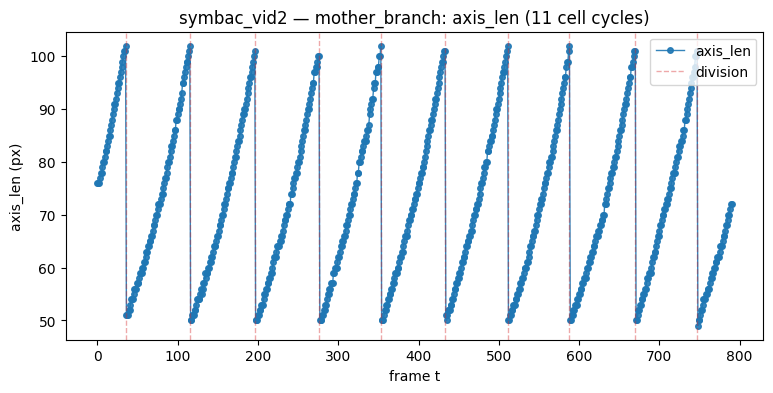

In [7]:
# Wrap the reconstructed run in a Lineage, trace the mother branch, and plot its
# length series (axis_len over time) — replaces plot_mother_length_series.
lin_A = Lineage.from_result(sel_A, ds)
branch_A = mother_branch(lin_A)
plot_property_series(lin_A, branch_A, prop="axis_len")

<Axes: title={'center': 'symbac_vid2 — lineage swimlane (43 tracks, 20 divisions)'}, xlabel='frame t', ylabel='y position (px) — closed end at top'>

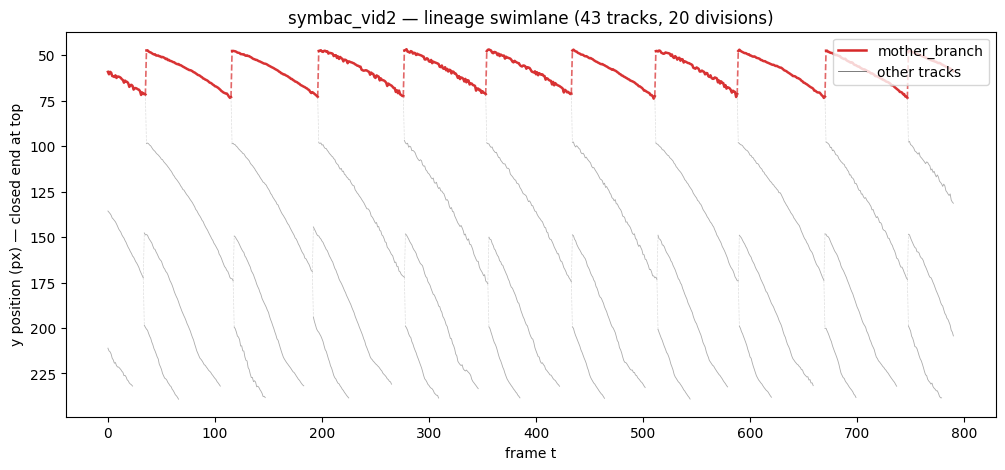

In [8]:
# Full lineage swimlane: every track's (t, y) trajectory, mother branch highlighted,
# division connectors dashed, y inverted so the closed end sits at the top.
plot_swimlane(lin_A, highlight=branch_A)

### New analysis views

Two things the module adds over the original notebook: the **dendrogram** and the **cycles table** (one row per `track_id`).

<Axes: title={'center': 'symbac_vid2 — lineage dendrogram (43 tracks, gen 0..10)'}, xlabel='frame t', ylabel='lineage layout (one band per subtree)'>

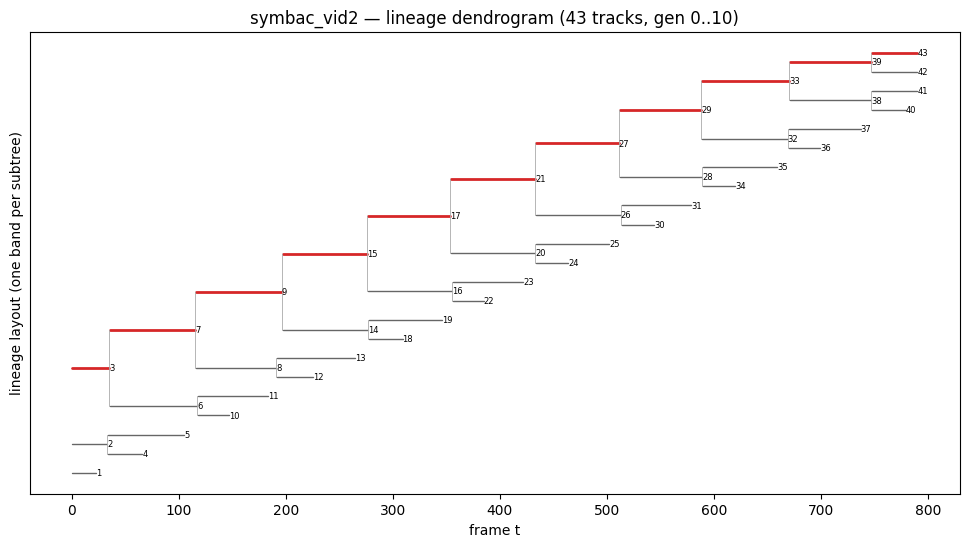

In [10]:
# Dendrogram, mother branch highlighted
plot_dendrogram(lin_A, highlight=branch_A)

In [11]:
# The cycles table: one row per track_id (a cell cycle). `complete_cycle` is the
# filter for interdivision statistics - observed birth AND division
lin_A.cycles.head(10)

,dataset_id,track_id,parent_id,generation,birth_t,end_t,n_frames,n_gap_frames,birth_observed,end_cause,complete_cycle
0,symbac_vid2,1,<NA>,0,0,23,24,0,False,exited,False
1,symbac_vid2,2,<NA>,0,0,33,34,0,False,divided,False
2,symbac_vid2,3,<NA>,0,0,35,36,0,False,divided,False
3,symbac_vid2,4,2,1,34,66,33,0,True,exited,False
4,symbac_vid2,5,2,1,34,105,72,0,True,exited,False
5,symbac_vid2,6,3,1,36,117,82,0,True,divided,True
6,symbac_vid2,7,3,1,36,115,80,0,True,divided,True
7,symbac_vid2,8,7,2,116,191,76,0,True,divided,True
8,symbac_vid2,9,7,2,116,196,81,0,True,divided,True
9,symbac_vid2,10,6,2,118,147,30,0,True,exited,False


## 5. One cell for all

<Axes: title={'center': 'symbac_vid2 — mother_branch: axis_len (11 cell cycles)'}, xlabel='frame t', ylabel='axis_len (px)'>

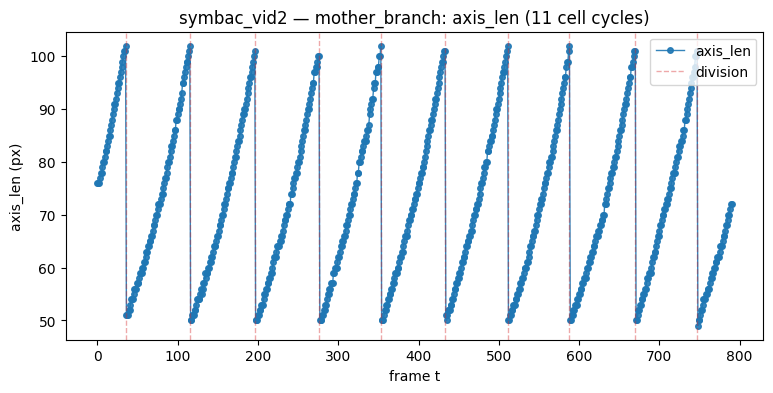

In [12]:
ds = DatasetSpec(
    dataset_id="symbac_vid2",
    labels_dir=EXAMPLE_DATA / "labels",
    axis="y",
    open_end="high",
)

candidates = run_track_generate(ds, top_k=16)

selections = run_track_select(
    ds,
    features=None,
    candidates=candidates.candidates_df,
    scorer="dp_cost_min",
    out_dir="/tmp/mm_pipeline_demo_B",
    run_tag="dp",
    overwrite=True,
)

lin = Lineage.from_result(selections, ds)
plot_property_series(lin, mother_branch(lin), prop="axis_len")

## 6. One cell for all (classifier-driven)

<Axes: title={'center': 'symbac_vid2 — mother_branch: axis_len (11 cell cycles)'}, xlabel='frame t', ylabel='axis_len (px)'>

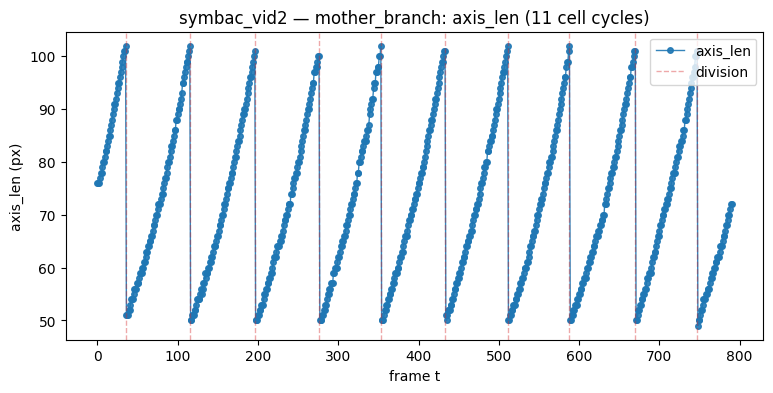

In [13]:
ds = DatasetSpec(
    dataset_id="symbac_vid2",
    labels_dir=EXAMPLE_DATA / "labels",
    axis="y",
    open_end="high",
)

candidates = run_track_generate(ds, top_k=16)

features = run_featurise(ds, candidates=candidates.candidates_df)

scored_candidates = run_score(features=features.features_df, model=scorer)

selections = run_track_select(
    ds,
    scored=scored_candidates.scored_df,
    scorer="classifier",
    out_dir="/tmp/mm_pipeline_demo_C",
    run_tag="rf",
    overwrite=True,
)

lin = Lineage.from_result(selections, ds)
plot_property_series(lin, mother_branch(lin), prop="axis_len")

## 7. Example B — Classifier-driven

Same trench, now with the scorer from §3 driving the within-pair pick. The candidates and features from Example A are reused — they don't depend on the scorer.

In [13]:
# Apply the trained scorer to the features from Example A.
scored = run_score(feat.features_df, model=scorer)
print(f"Scored: added columns {sorted(set(scored.scored_df.columns) - set(feat.features_df.columns))}")

Scored: added columns ['candidate_correctness_probability', 'pair_prob', 'pair_probability', 'pair_score_rank', 'raw_score', 'raw_score_kind', 'score_feature_subset', 'score_is_calibrated', 'score_model', 'score_rank', 'y_score']


In [14]:
# track-select with classifier-driven within-pair picks.
sel_B = run_track_select(
    ds,
    scored=scored.scored_df,
    scorer="classifier",
    out_dir="/tmp/mm_pipeline_demo_B",
    run_tag="cls",
    overwrite=True,
)
tracks_B = sel_B.tracks_by_dataset[ds.dataset_id]
divs_B = sel_B.divisions_by_dataset[ds.dataset_id]
print(f"Reconstructed {tracks_B['track_id'].nunique()} tracks "
      f"across {tracks_B['t'].nunique()} frames, with {len(divs_B)} divisions.")

Reconstructed 43 tracks across 791 frames, with 20 divisions.


<Axes: title={'center': 'symbac_vid2 — mother_branch: axis_len (11 cell cycles)'}, xlabel='frame t', ylabel='axis_len (px)'>

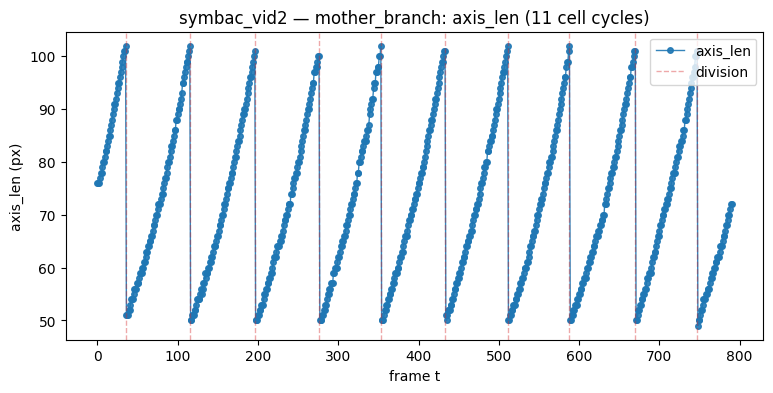

In [15]:
# Mother-lineage length series for the classifier-driven run.
lin_B = Lineage.from_result(sel_B, ds)
branch_B = mother_branch(lin_B)
plot_property_series(lin_B, branch_B, prop="axis_len")

<Axes: title={'center': 'symbac_vid2 — lineage swimlane (43 tracks, 20 divisions)'}, xlabel='frame t', ylabel='y position (px) — closed end at top'>

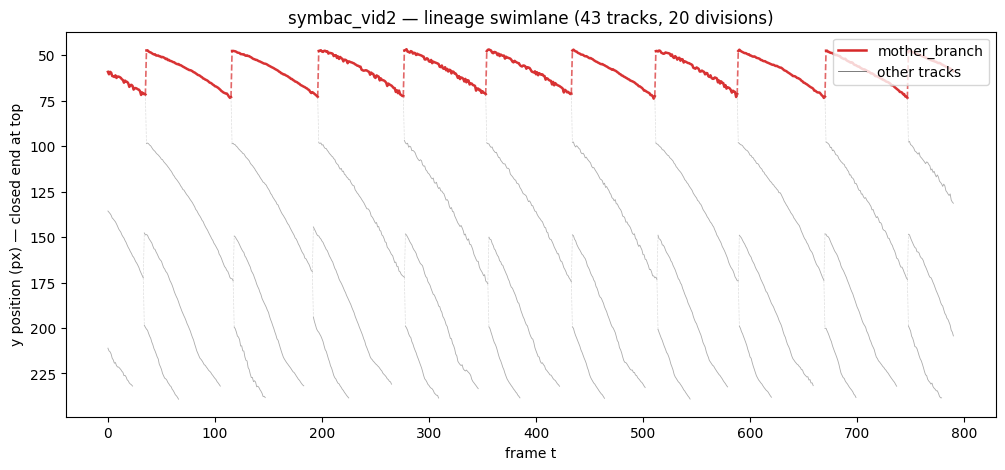

In [16]:
# Full lineage swimlane for the classifier-driven run.
plot_swimlane(lin_B, highlight=branch_B)